# Imports

In [2]:
from config import Config
from data import ImagePairDataset
import matplotlib.pyplot as plt
from model import ImagePairMatcher
import numpy as np
from train import EarlyStopper
from train import randomized_search, run_pipeline, test
import torch
from torch import device, nn, optim
from torch.utils.data import DataLoader

# Default Model

In [ ]:
config = Config(NUM_EPOCHS=3)
results = run_pipeline(config)

In [ ]:
results.model.parameter_count()

In [ ]:
plt.plot(results.train_results.train_losses, label='training')
plt.plot(results.train_results.validate_losses, label='validation')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [ ]:
plt.plot(results.train_results.train_accuracies, label='training')
plt.plot(results.train_results.validate_accuracies, label='validation')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
test_loader = DataLoader(ImagePairDataset(split='test'), batch_size=128)

In [ ]:
test_results = test(results.model, results.criterion, test_loader, device('cuda'))

In [ ]:
print(f'(Loss) training: {round(results.train_results.train_losses[-1], 2)}, ' + 
      f'validation: {round(results.train_results.validate_losses[-1], 2)}, ' + 
      f'testing: {round(test_results.test_loss, 2)}' + 
      f'\n(Accuracy) training: {round(100 * results.train_results.train_accuracies[-1], 2)}%, ' + 
      f'validation: {round(100 * results.train_results.validate_accuracies[-1], 2)}%, ' + 
      f'testing: {round(100 * test_results.test_accuracy, 2)}%')

# Hyperparameter Search

In [2]:
param_grid = {
    'CNN_DROPOUT': np.linspace(0.0, 0.3, num=4),
    'FC_DROPOUT': np.linspace(0.0, 0.3, num=4),
    'LEARNING_RATE': np.logspace(-4, -2, num=20),
    'WEIGHT_DECAY': np.logspace(-4, -2, num=7)
}

In [3]:
tune_results = randomized_search(param_grid, 100)

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [5:11:07<00:00, 186.68s/it]


In [4]:
tune_results.best_config

Config(CNN_HIDDEN_CHANNELS_1=16, CNN_HIDDEN_CHANNELS_2=32, CNN_OUT_CHANNELS=64, CNN_DROPOUT=np.float64(0.0), FC_HIDDEN_1=32, FC_HIDDEN_2=16, FC_DROPOUT=np.float64(0.0), NUM_EPOCHS=20, LEARNING_RATE=np.float64(0.002335721469090121), WEIGHT_DECAY=np.float64(0.00021544346900318845), PATIENCE=None, DELTA=None)

In [7]:
for config, score in tune_results.scores.items():
    print(score)
    print(config)
    print()

0.32071682328586615
Config(CNN_HIDDEN_CHANNELS_1=16, CNN_HIDDEN_CHANNELS_2=32, CNN_OUT_CHANNELS=64, CNN_DROPOUT=np.float64(0.09999999999999999), FC_HIDDEN_1=32, FC_HIDDEN_2=16, FC_DROPOUT=np.float64(0.0), NUM_EPOCHS=20, LEARNING_RATE=np.float64(0.002335721469090121), WEIGHT_DECAY=np.float64(0.002154434690031882), PATIENCE=None, DELTA=None)

0.3435346080588439
Config(CNN_HIDDEN_CHANNELS_1=16, CNN_HIDDEN_CHANNELS_2=32, CNN_OUT_CHANNELS=64, CNN_DROPOUT=np.float64(0.19999999999999998), FC_HIDDEN_1=32, FC_HIDDEN_2=16, FC_DROPOUT=np.float64(0.0), NUM_EPOCHS=20, LEARNING_RATE=np.float64(0.0014384498882876629), WEIGHT_DECAY=np.float64(0.00046415888336127773), PATIENCE=None, DELTA=None)

0.44041862581102176
Config(CNN_HIDDEN_CHANNELS_1=16, CNN_HIDDEN_CHANNELS_2=32, CNN_OUT_CHANNELS=64, CNN_DROPOUT=np.float64(0.19999999999999998), FC_HIDDEN_1=32, FC_HIDDEN_2=16, FC_DROPOUT=np.float64(0.0), NUM_EPOCHS=20, LEARNING_RATE=np.float64(0.00379269019073225), WEIGHT_DECAY=np.float64(0.004641588833612777)

# Evaluate Optimal Model

In [3]:
best_config = Config(CNN_HIDDEN_CHANNELS_1=16, 
                     CNN_HIDDEN_CHANNELS_2=32, 
                     CNN_OUT_CHANNELS=64, 
                     CNN_DROPOUT=np.float64(0.0), 
                     FC_HIDDEN_1=32, 
                     FC_HIDDEN_2=16, 
                     FC_DROPOUT=np.float64(0.0), 
                     NUM_EPOCHS=20, 
                     LEARNING_RATE=np.float64(0.002335721469090121), 
                     WEIGHT_DECAY=np.float64(0.00021544346900318845), 
                     PATIENCE=None, 
                     DELTA=None)

In [4]:
results = run_pipeline(best_config)

train batches: 100%|███████████████████████████████████████████████████████████████| 7840/7840 [02:10<00:00, 60.07it/s]


In [10]:
results.model.parameter_count()

32465

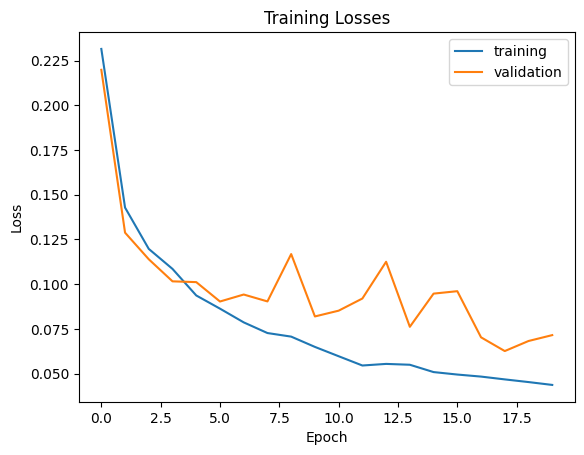

In [5]:
plt.plot(results.train_results.train_losses, label='training')
plt.plot(results.train_results.validate_losses, label='validation')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

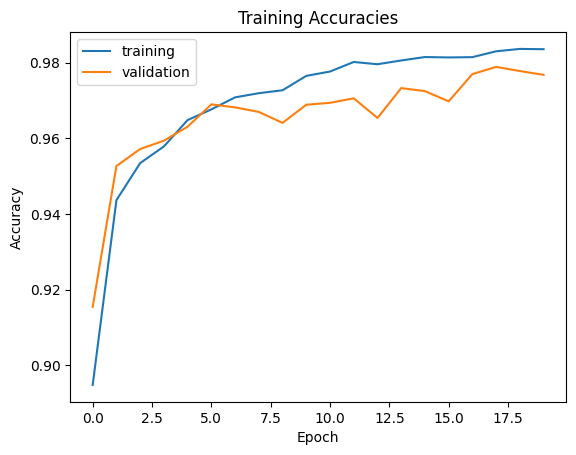

In [6]:
plt.plot(results.train_results.train_accuracies, label='training')
plt.plot(results.train_results.validate_accuracies, label='validation')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [7]:
test_loader = DataLoader(ImagePairDataset(split='test'), batch_size=128)

In [8]:
test_results = test(results.model, results.criterion, test_loader, device('cuda'))

test batches: 100%|████████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 32.94it/s]


In [9]:
print(f'(Loss) training: {round(results.train_results.train_losses[-1], 2)}, ' + 
      f'validation: {round(results.train_results.validate_losses[-1], 2)}, ' + 
      f'testing: {round(test_results.test_loss, 2)}' + 
      f'\n(Accuracy) training: {round(100 * results.train_results.train_accuracies[-1], 2)}%, ' + 
      f'validation: {round(100 * results.train_results.validate_accuracies[-1], 2)}%, ' + 
      f'testing: {round(100 * test_results.test_accuracy, 2)}%')

(Loss) training: 0.04, validation: 0.07, testing: 0.07
(Accuracy) training: 98.36%, validation: 97.68%, testing: 97.93%


In [11]:
torch.save(results.model, 'best_model.pt')